# Bank Marketing Campaign Analysis – Predicting Term Deposit Subscription

**Author:** Ibrahim  
**Environment:** Google Colab / Python 3

## Overview
This project analyses direct marketing campaigns (phone calls) of a Portuguese bank. It predicts whether a client will subscribe to a term deposit based on demographic, campaign, and economic data. The insights help the bank target the right customers, reduce call costs, and improve conversion rates.

## Dataset
- **Source:** UCI Bank Marketing Dataset
- **Rows:** 41,188 contacts
- **Columns:** age, job, marital, education, default, housing, loan, contact, month, duration, campaign, pdays, previous, poutcome, emp_var_rate, cons_price_idx, euribor3m, nr_employed, y (target)

## Key Steps
1. Data cleaning (map target to binary)
2. Exploratory analysis with visualisations
3. Feature encoding and logistic regression
4. Model evaluation and feature importance

## Requirements
- pandas, matplotlib, seaborn, scikit-learn

---

**© 2026 Ibrahim – Bank marketing analytics.**

### Install & Imports

In [35]:
!pip install -q pandas matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import warnings
warnings.filterwarnings('ignore')

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

### Load Dataset

In [37]:
import requests
import zipfile
import io

# Download from UCI (direct link)
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00222/bank-additional.zip"
response = requests.get(url)

# Check if the request was successful
if response.status_code == 200:
    # Read the content of the zip file
    with zipfile.ZipFile(io.BytesIO(response.content)) as z:
        # Find the specific CSV file within the zip (bank-additional-full.csv)
        with z.open('bank-additional/bank-additional-full.csv') as csv_file:
            df = pd.read_csv(csv_file, sep=';')
else:
    print(f"Failed to download the file. Status code: {response.status_code}")

print("Dataset shape:", df.shape)
df.head(2)

Dataset shape: (41188, 21)


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Data Cleaning & Target Encoding

In [38]:
# Convert target 'y' to binary (1 for yes, 0 for no)
df['y'] = df['y'].map({'yes': 1, 'no': 0})

# Check class balance
print(f"Subscription rate: {df['y'].mean()*100:.2f}%")
print(f"Total contacts: {len(df)}")

Subscription rate: 11.27%
Total contacts: 41188


### Target Distribution

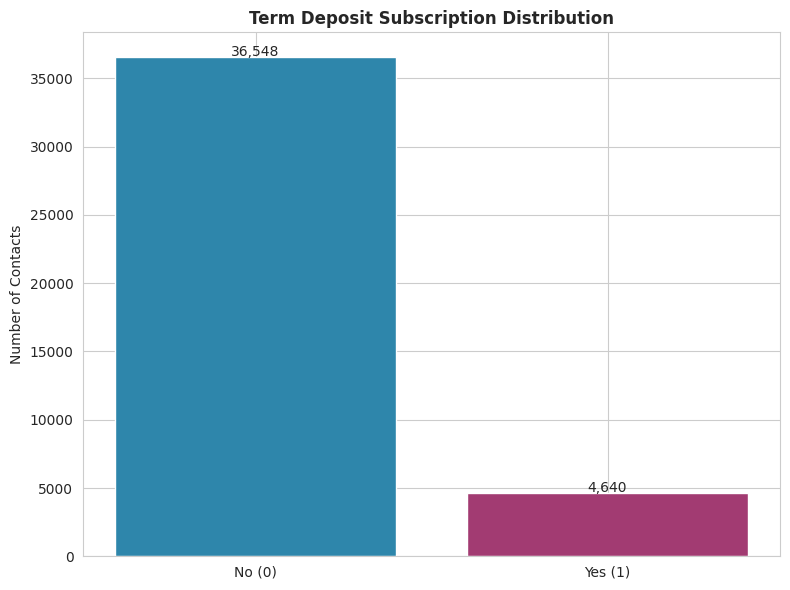

In [39]:
target_counts = df['y'].value_counts()

plt.figure(figsize=(8, 6))
bars = plt.bar(['No (0)', 'Yes (1)'], target_counts.values, color=['#2E86AB', '#A23B72'])
plt.ylabel('Number of Contacts')
plt.title('Term Deposit Subscription Distribution', fontweight='bold')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 100, f'{height:,}', ha='center')
plt.tight_layout()
plt.show()

### Age Distribution by Subscription

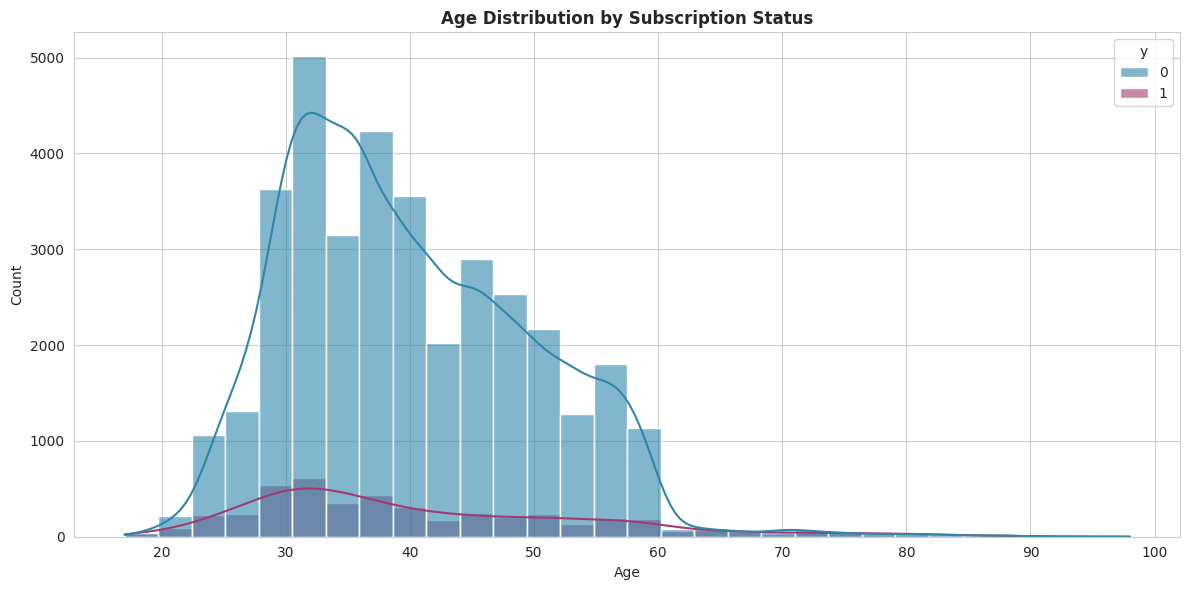

In [40]:
plt.figure(figsize=(12, 6))
sns.histplot(data=df, x='age', hue='y', bins=30, kde=True, palette=['#2E86AB', '#A23B72'], alpha=0.6)
plt.xlabel('Age')
plt.ylabel('Count')
plt.title('Age Distribution by Subscription Status', fontweight='bold')
plt.tight_layout()
plt.show()

### Subscription Rate by Job Category

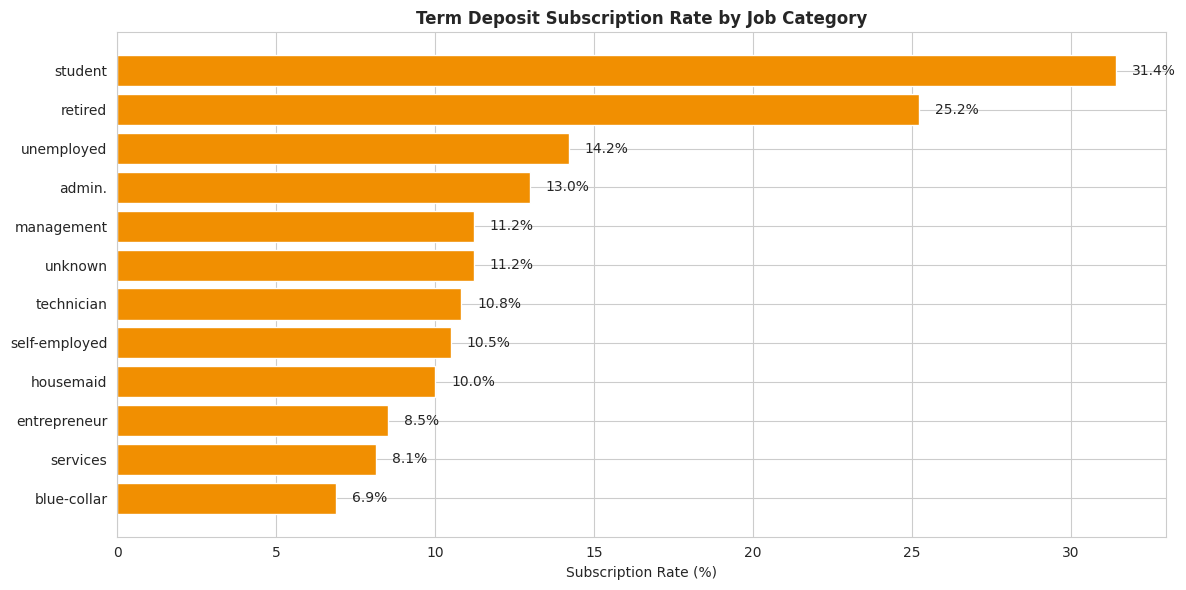

In [41]:
job_sub = df.groupby('job')['y'].mean().sort_values() * 100

plt.figure(figsize=(12, 6))
bars = plt.barh(job_sub.index, job_sub.values, color='#F18F01')
plt.xlabel('Subscription Rate (%)')
plt.title('Term Deposit Subscription Rate by Job Category', fontweight='bold')
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2, f'{width:.1f}%', va='center')
plt.tight_layout()
plt.show()

### Subscription Rate by Marital Status

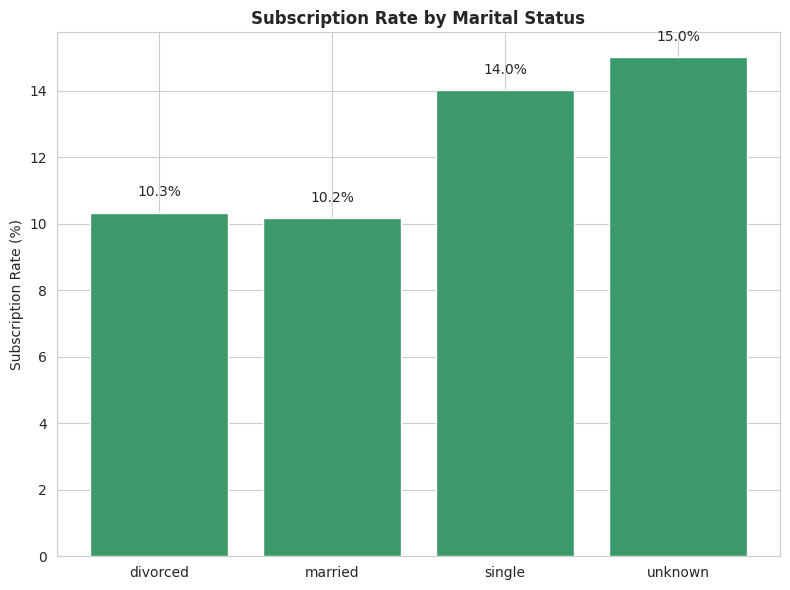

In [42]:
marital_sub = df.groupby('marital')['y'].mean() * 100

plt.figure(figsize=(8, 6))
bars = plt.bar(marital_sub.index, marital_sub.values, color='#3C9A6A')
plt.ylabel('Subscription Rate (%)')
plt.title('Subscription Rate by Marital Status', fontweight='bold')
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + 0.5, f'{height:.1f}%', ha='center')
plt.tight_layout()
plt.show()

### Subscription by Contact Month

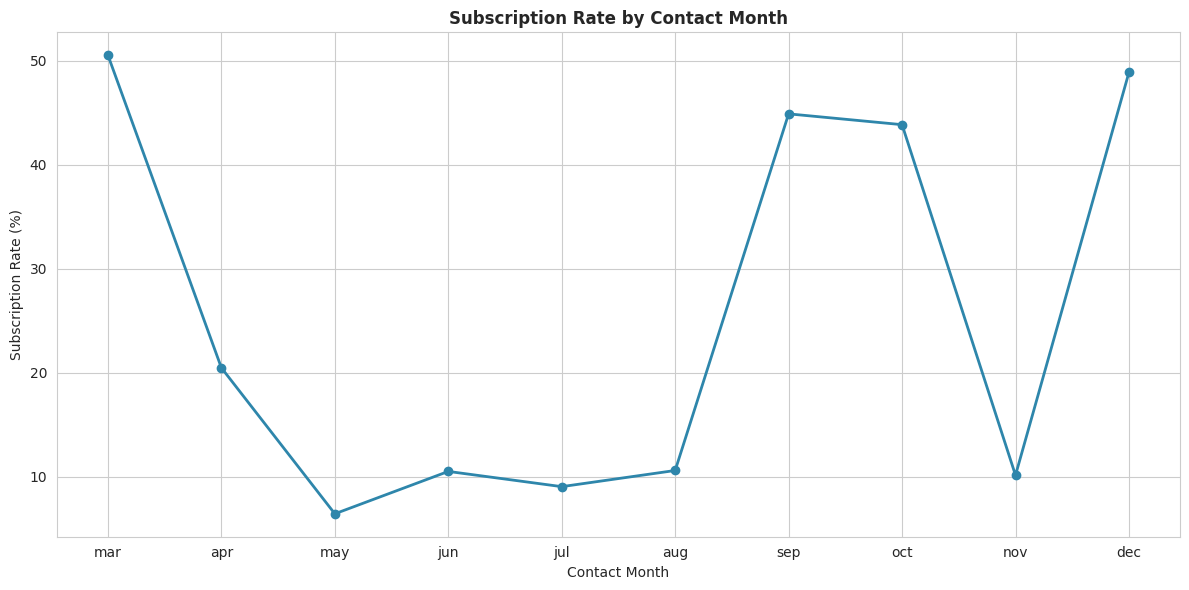

In [43]:
month_order = ['mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
monthly_sub = df.groupby('month')['y'].mean() * 100
monthly_sub = monthly_sub.reindex(month_order)

plt.figure(figsize=(12, 6))
plt.plot(monthly_sub.index, monthly_sub.values, marker='o', linewidth=2, color='#2E86AB')
plt.xlabel('Contact Month')
plt.ylabel('Subscription Rate (%)')
plt.title('Subscription Rate by Contact Month', fontweight='bold')
plt.grid(True)
plt.tight_layout()
plt.show()

### Call Duration vs Subscription (Box Plot)

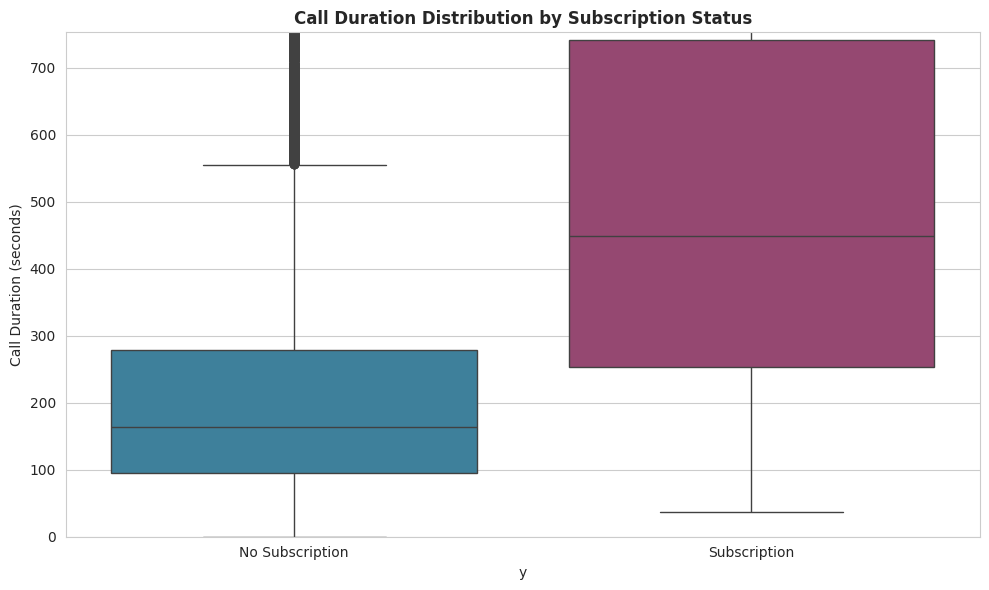

In [44]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='y', y='duration', palette=['#2E86AB', '#A23B72'])
plt.xticks([0,1], ['No Subscription', 'Subscription'])
plt.ylim(0, df['duration'].quantile(0.95))
plt.ylabel('Call Duration (seconds)')
plt.title('Call Duration Distribution by Subscription Status', fontweight='bold')
plt.tight_layout()
plt.show()

### Correlation Heatmap

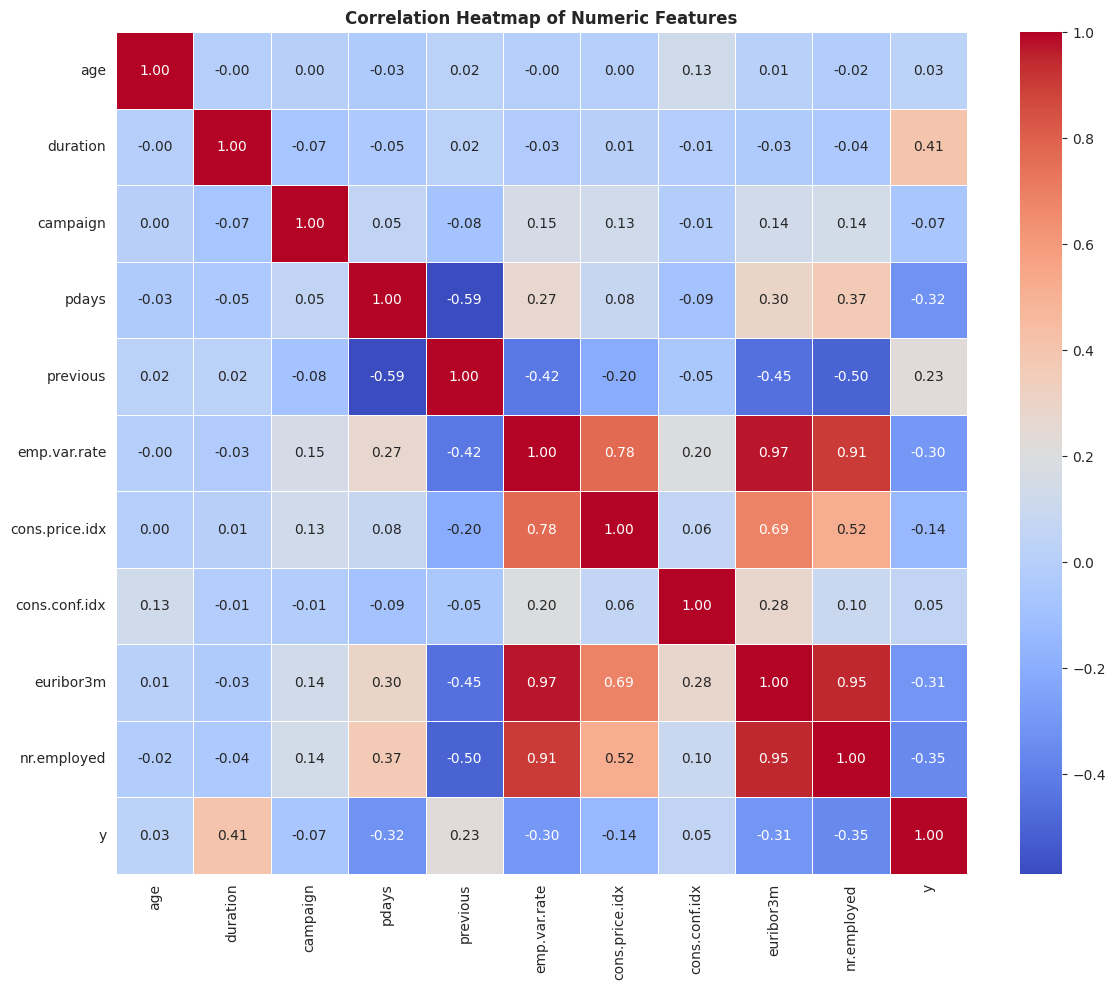

In [46]:
numeric_cols = ['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'y']
corr = df[numeric_cols].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Features', fontweight='bold')
plt.tight_layout()
plt.show()

### Feature Importance from Logistic Regression

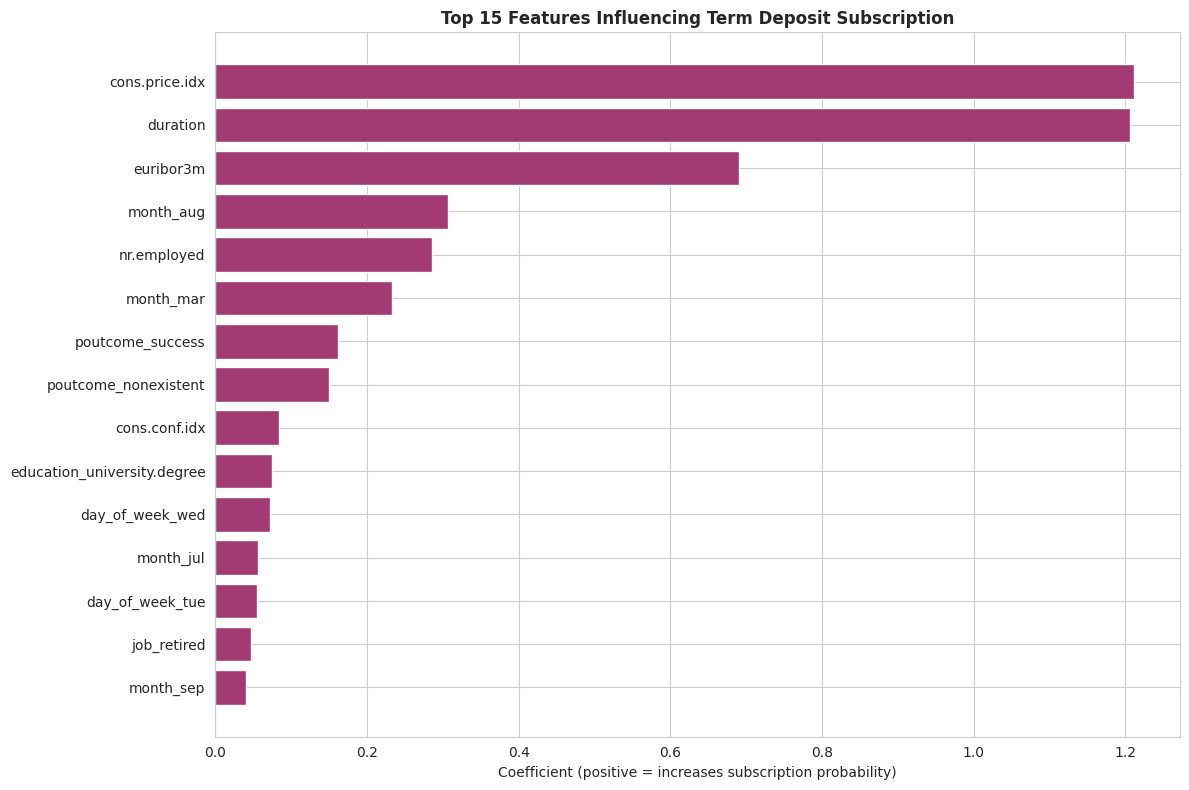

In [48]:
# Select features and encode categoricals
categorical_cols = ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'poutcome', 'month', 'day_of_week']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Prepare X and y
X = df_encoded.drop('y', axis=1)
y = df_encoded['y']

# Scale numeric features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train model
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

# Feature importance (coefficients)
feature_names = X.columns
coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': model.coef_[0]})
coef_df = coef_df.sort_values('Coefficient', ascending=False).head(15)

plt.figure(figsize=(12, 8))
bars = plt.barh(coef_df['Feature'][::-1], coef_df['Coefficient'][::-1], color=['#A23B72' if c>0 else '#2E86AB' for c in coef_df['Coefficient'][::-1]])
plt.xlabel('Coefficient (positive = increases subscription probability)')
plt.title('Top 15 Features Influencing Term Deposit Subscription', fontweight='bold')
plt.tight_layout()
plt.show()

### Confusion Matrix

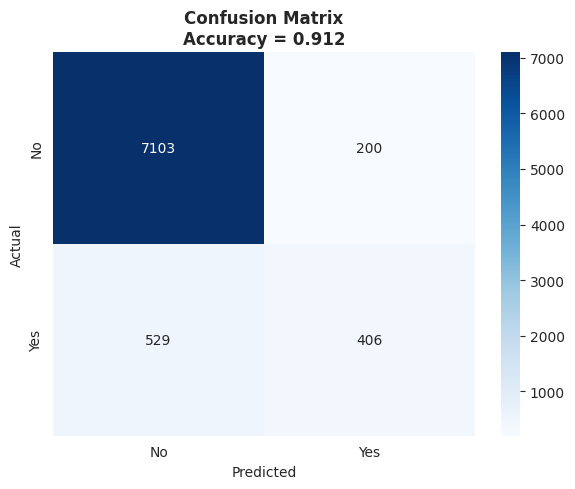

              precision    recall  f1-score   support

           0       0.93      0.97      0.95      7303
           1       0.67      0.43      0.53       935

    accuracy                           0.91      8238
   macro avg       0.80      0.70      0.74      8238
weighted avg       0.90      0.91      0.90      8238



In [49]:
y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix\nAccuracy = {accuracy_score(y_test, y_pred):.3f}', fontweight='bold')
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred))

### Key Insights Summary

In [51]:
poutcome_sub = df.groupby('poutcome')['y'].mean() * 100

print(" Key Insights from Bank Marketing Analysis")
print(f" Overall subscription rate: {df['y'].mean()*100:.2f}%")
print(f" Best performing job category: {job_sub.idxmax()} ({job_sub.max():.1f}%)")
print(f" Most effective contact month: {monthly_sub.idxmax()} ({monthly_sub.max():.1f}%)")
print(f"⏱ Average call duration (subscribers vs non): {df[df['y']==1]['duration'].mean():.0f}s vs {df[df['y']==0]['duration'].mean():.0f}s")
print(f" Previous success has huge impact: {poutcome_sub['success']:.1f}% subscription rate")
print(" Logistic regression model built and evaluated.")

 Key Insights from Bank Marketing Analysis
 Overall subscription rate: 11.27%
 Best performing job category: student (31.4%)
 Most effective contact month: mar (50.5%)
⏱ Average call duration (subscribers vs non): 553s vs 221s
 Previous success has huge impact: 65.1% subscription rate
 Logistic regression model built and evaluated.


### Final Summary

In [52]:
print("Bank Marketing Campaign Analysis - COMPLETED")
print("Author: Ibrahim")
print("Dataset cleaned and explored.")
print("Key drivers of subscription identified.")
print("Model ready for campaign optimisation.")

Bank Marketing Campaign Analysis - COMPLETED
Author: Ibrahim
Dataset cleaned and explored.
Key drivers of subscription identified.
Model ready for campaign optimisation.
